In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# CHEMIN DU DATASET
# ============================================
base_path = '/kaggle/input/datasets/benafialoua/beauty-commerce'

# Fallback automatique si le chemin change
if not os.path.exists(os.path.join(base_path, 'orders.csv')):
    print(f" Chemin '{base_path}' invalide, recherche automatique...")
    base_path = None
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'orders.csv' in files:
            base_path = root
            break
    if base_path is None:
        raise FileNotFoundError("Impossible de trouver 'orders.csv' dans /kaggle/input")

print(f"✅ Dataset path: {base_path}")

# ============================================
# CHARGEMENT DES DONNÉES PRINCIPALES
# ============================================
orders = pd.read_csv(os.path.join(base_path, 'orders.csv'))
customers = pd.read_csv(os.path.join(base_path, 'customers.csv'))
order_items = pd.read_csv(os.path.join(base_path, 'order_items.csv'))
products = pd.read_csv(os.path.join(base_path, 'products.csv'))
brands = pd.read_csv(os.path.join(base_path, 'brands.csv'))

# Conversion des dates
orders['order_purchase_ts'] = pd.to_datetime(orders['order_purchase_ts'])
customers['signup_date'] = pd.to_datetime(customers['signup_date'])

# ============================================
# VUE D'ENSEMBLE
# ============================================
print("\n=== ORDERS ===")
print(orders.info())
print(orders.describe())
print(f"\nPériode: {orders['order_purchase_ts'].min()} → {orders['order_purchase_ts'].max()}")
print(f"Clients uniques: {orders['customer_unique_id'].nunique()}")
print(f"Commandes: {len(orders)}")

✅ Dataset path: /kaggle/input/datasets/benafialoua/beauty-commerce

=== ORDERS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1564619 entries, 0 to 1564618
Data columns (total 14 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   order_id                  1564619 non-null  object        
 1   customer_unique_id        1564619 non-null  object        
 2   customer_country          1564619 non-null  object        
 3   marketing_channel         1564619 non-null  object        
 4   is_new_customer           1564619 non-null  bool          
 5   order_status              1564619 non-null  object        
 6   order_purchase_ts         1564619 non-null  datetime64[ns]
 7   order_approved_ts         1548882 non-null  object        
 8   order_delivered_ts        1548882 non-null  object        
 9   order_estimated_delivery  1564619 non-null  object        
 10  n_items                   15646

In [22]:
# Chargement des fichiers complémentaires
reviews = pd.read_csv(os.path.join(base_path, 'order_reviews.csv'))
payments = pd.read_csv(os.path.join(base_path, 'order_payments.csv'))
inventory = pd.read_csv(os.path.join(base_path, 'inventory_snapshots.csv'))
purchase_orders = pd.read_csv(os.path.join(base_path, 'purchase_orders.csv'))
marketing_campaigns = pd.read_csv(os.path.join(base_path, 'marketing_campaigns.csv'))
marketing_perf = pd.read_csv(os.path.join(base_path, 'marketing_performance.csv'))
warehouses = pd.read_csv(os.path.join(base_path, 'warehouses.csv'))
geolocation = pd.read_csv(os.path.join(base_path, 'geolocation.csv'))

# Conversion des dates
reviews['review_creation_ts'] = pd.to_datetime(reviews['review_creation_ts'])
reviews['review_answer_ts'] = pd.to_datetime(reviews['review_answer_ts'])
purchase_orders['order_date'] = pd.to_datetime(purchase_orders['order_date'])
purchase_orders['expected_date'] = pd.to_datetime(purchase_orders['expected_date'])
marketing_campaigns['start_date'] = pd.to_datetime(marketing_campaigns['start_date'])
marketing_campaigns['end_date'] = pd.to_datetime(marketing_campaigns['end_date'])
marketing_perf['week'] = pd.to_datetime(marketing_perf['week'])

print("✅ Fichiers complémentaires chargés")
for name, df in [('reviews', reviews), ('payments', payments), ('inventory', inventory),
                 ('purchase_orders', purchase_orders), ('marketing_campaigns', marketing_campaigns),
                 ('marketing_perf', marketing_perf), ('warehouses', warehouses),
                 ('geolocation', geolocation)]:
    print(f"  {name}: {df.shape}")

✅ Fichiers complémentaires chargés
  reviews: (1363255, 4)
  payments: (1564619, 4)
  inventory: (168000, 6)
  purchase_orders: (74228, 8)
  marketing_campaigns: (112, 6)
  marketing_perf: (1680, 8)
  warehouses: (1, 5)
  geolocation: (10, 4)


In [23]:
dataframes = {
    'orders': orders, 'customers': customers, 'order_items': order_items,
    'products': products, 'brands': brands, 'reviews': reviews,
    'payments': payments, 'inventory': inventory,
    'purchase_orders': purchase_orders, 'marketing_campaigns': marketing_campaigns,
    'marketing_perf': marketing_perf, 'warehouses': warehouses, 'geolocation': geolocation,
}

for name, df in dataframes.items():
    print(f"\n{'='*60}")
    print(f"📁 {name} — {df.shape[0]} lignes × {df.shape[1]} colonnes")
    print(f"{'='*60}")
    missing = df.isna().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print("⚠️ Valeurs manquantes :")
        print((missing / len(df) * 100).round(2).to_string())
    else:
        print("✅ Aucune valeur manquante")
    print(f"🔁 Doublons complets : {df.duplicated().sum()}")


📁 orders — 1564619 lignes × 14 colonnes
⚠️ Valeurs manquantes :
order_approved_ts     1.01
order_delivered_ts    1.01
🔁 Doublons complets : 0

📁 customers — 1013883 lignes × 4 colonnes
✅ Aucune valeur manquante
🔁 Doublons complets : 0

📁 order_items — 2372597 lignes × 7 colonnes
✅ Aucune valeur manquante
🔁 Doublons complets : 0

📁 products — 3500 lignes × 7 colonnes
✅ Aucune valeur manquante
🔁 Doublons complets : 0

📁 brands — 116 lignes × 5 colonnes
✅ Aucune valeur manquante
🔁 Doublons complets : 0

📁 reviews — 1363255 lignes × 4 colonnes
✅ Aucune valeur manquante
🔁 Doublons complets : 0

📁 payments — 1564619 lignes × 4 colonnes
✅ Aucune valeur manquante
🔁 Doublons complets : 0

📁 inventory — 168000 lignes × 6 colonnes
✅ Aucune valeur manquante
🔁 Doublons complets : 0

📁 purchase_orders — 74228 lignes × 8 colonnes
✅ Aucune valeur manquante
🔁 Doublons complets : 0

📁 marketing_campaigns — 112 lignes × 6 colonnes
✅ Aucune valeur manquante
🔁 Doublons complets : 0

📁 marketing_perf — 168

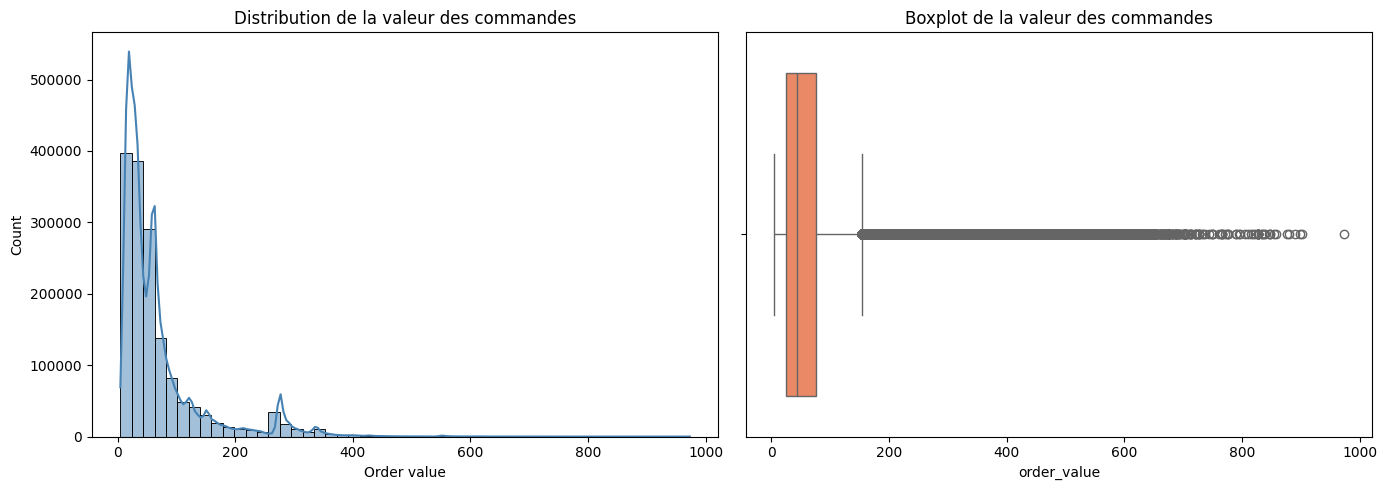

Order value — mean: 69.37
Order value — median: 43.49
Order value — max: 972.79


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(orders['order_value'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution de la valeur des commandes')
axes[0].set_xlabel('Order value')

sns.boxplot(x=orders['order_value'], ax=axes[1], color='coral')
axes[1].set_title('Boxplot de la valeur des commandes')

plt.tight_layout()
plt.show()

print(f"Order value — mean: {orders['order_value'].mean():.2f}")
print(f"Order value — median: {orders['order_value'].median():.2f}")
print(f"Order value — max: {orders['order_value'].max():.2f}")

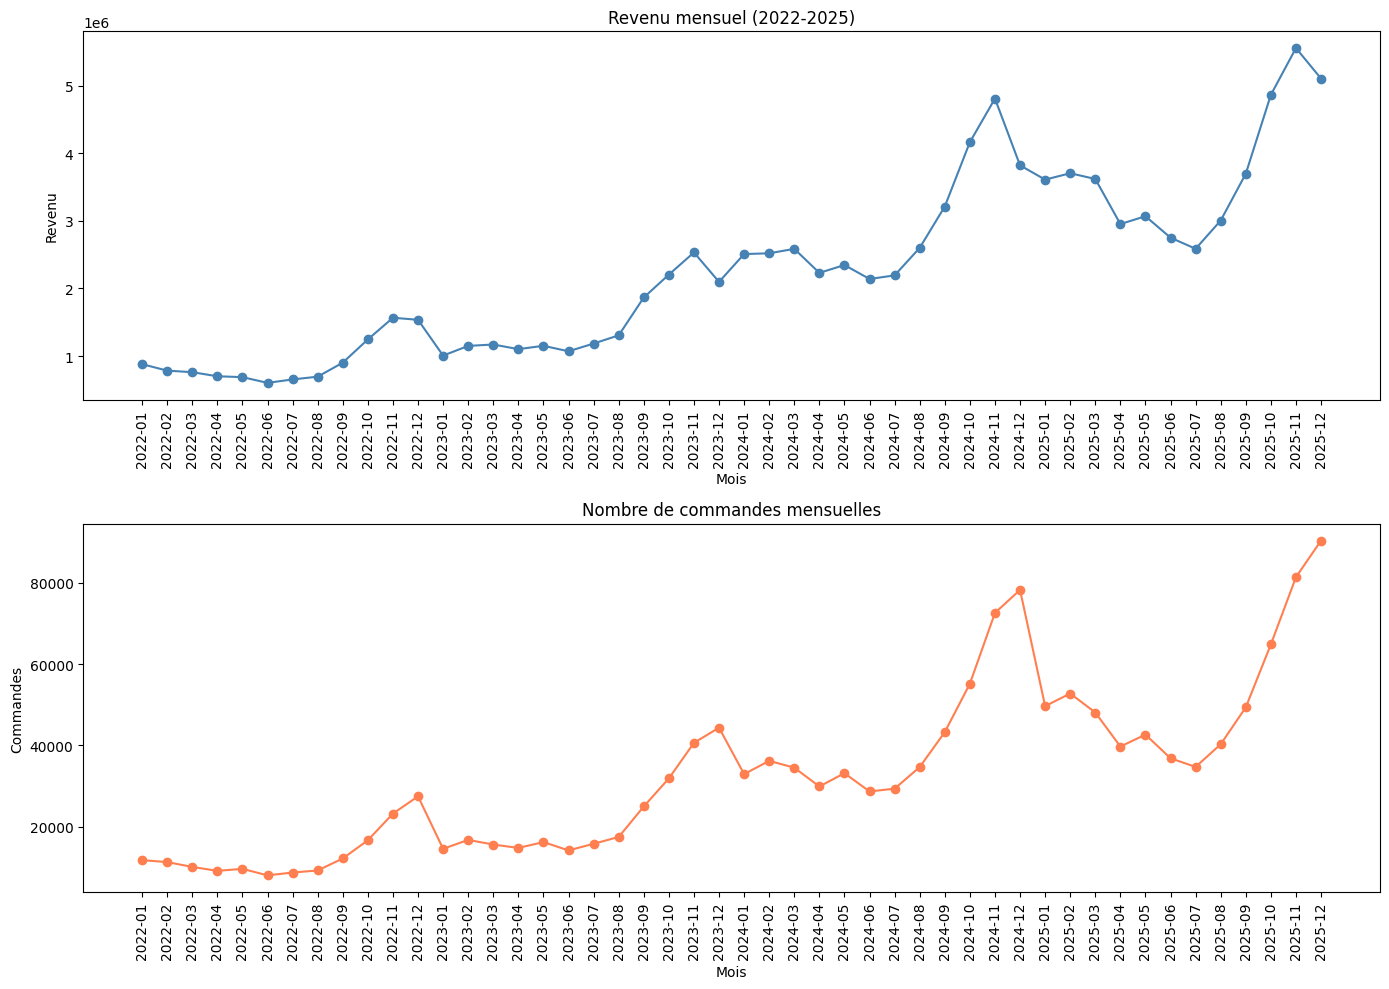

In [25]:
orders['year_month'] = orders['order_purchase_ts'].dt.to_period('M').astype(str)
monthly_revenue = orders.groupby('year_month')['order_value'].sum()
monthly_orders = orders.groupby('year_month')['order_id'].count()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='steelblue')
axes[0].set_title('Revenu mensuel (2022-2025)')
axes[0].set_xlabel('Mois')
axes[0].set_ylabel('Revenu')
axes[0].tick_params(axis='x', rotation=90)

axes[1].plot(monthly_orders.index, monthly_orders.values, marker='o', color='coral')
axes[1].set_title('Nombre de commandes mensuelles')
axes[1].set_xlabel('Mois')
axes[1].set_ylabel('Commandes')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

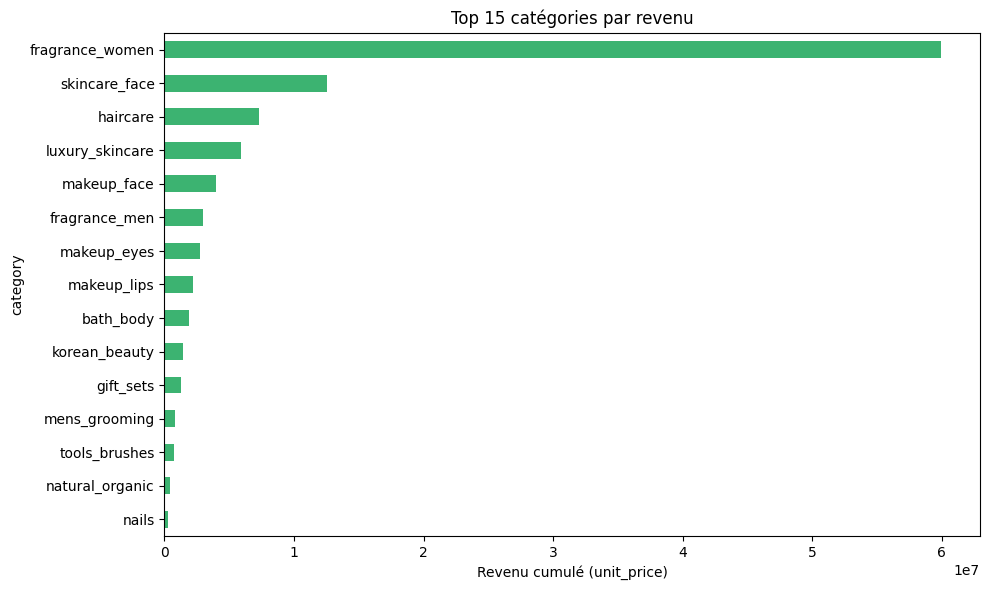

category
fragrance_women    59941195.10
skincare_face      12518809.46
haircare            7290654.20
luxury_skincare     5904540.48
makeup_face         3981875.74
fragrance_men       2992060.38
makeup_eyes         2772546.57
makeup_lips         2244739.48
bath_body           1888533.86
korean_beauty       1436185.64
gift_sets           1285896.27
mens_grooming        794639.71
tools_brushes        709092.86
natural_organic      454945.58
nails                279678.37
Name: unit_price, dtype: float64

📊 Top 10 marques par revenu (brand_id) :
brand_id
BR029    81675179.82
BR109     5211415.02
BR048     2048410.05
BR054     1385062.60
BR091      694317.09
BR087      692169.37
BR075      574462.51
BR113      564509.98
BR085      549236.92
BR101      492417.16
Name: unit_price, dtype: float64


In [26]:
# ⚠️ 'category' existe DÉJÀ dans order_items → pas besoin de jointure
category_revenue = (
    order_items
    .groupby('category')['unit_price']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 6))
category_revenue.plot(kind='barh', ax=ax, color='mediumseagreen')
ax.set_title('Top 15 catégories par revenu')
ax.set_xlabel('Revenu cumulé (unit_price)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(category_revenue)

# Bonus : top marques (brand_id existe aussi dans order_items)
top_brands = (
    order_items
    .groupby('brand_id')['unit_price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print("\n📊 Top 10 marques par revenu (brand_id) :")
print(top_brands)

/tmp/ipykernel_58/1997847613.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='review_score', data=reviews, ax=axes[0], palette='viridis')


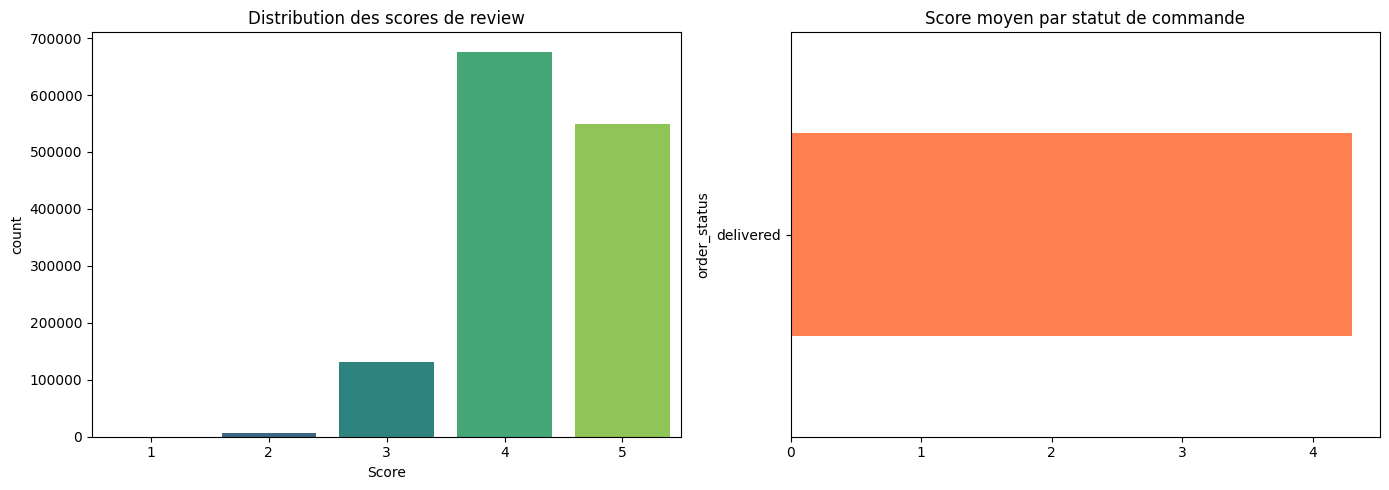

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='review_score', data=reviews, ax=axes[0], palette='viridis')
axes[0].set_title('Distribution des scores de review')
axes[0].set_xlabel('Score')

reviews_orders = reviews.merge(
    orders[['order_id', 'order_status']],
    on='order_id',
    how='left'
)
avg_score_by_status = reviews_orders.groupby('order_status')['review_score'].mean().sort_values()
avg_score_by_status.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Score moyen par statut de commande')

plt.tight_layout()
plt.show()

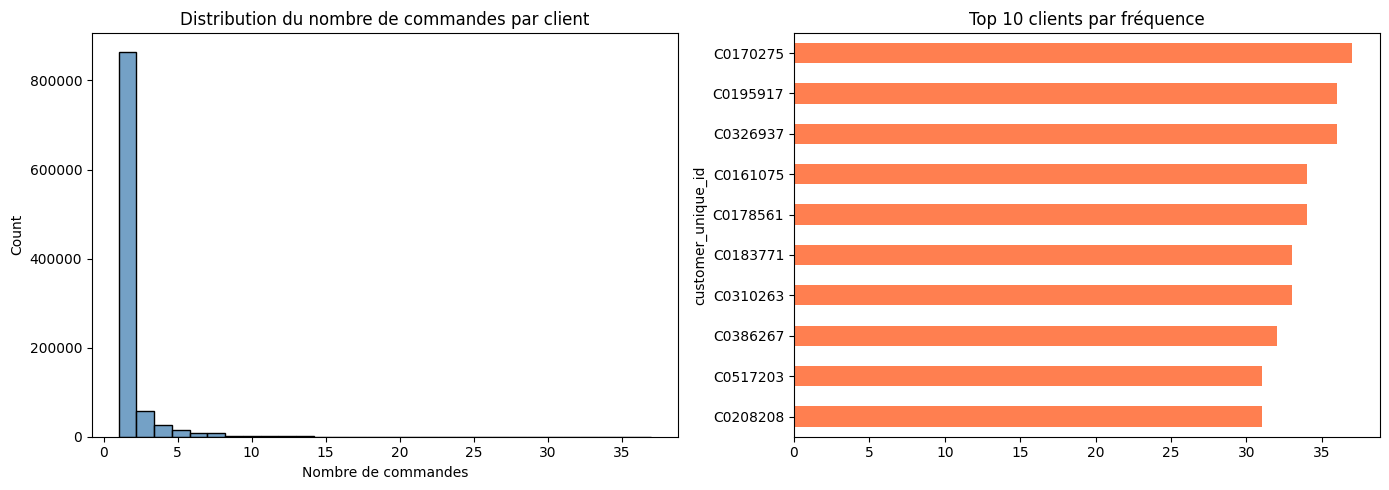

Fréquence moyenne: 1.59
Clients avec 1 seule commande: 704215 (71.4%)
Clients avec >5 commandes: 23236


In [28]:
customer_freq = orders.groupby('customer_unique_id')['order_id'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(customer_freq, bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution du nombre de commandes par client')
axes[0].set_xlabel('Nombre de commandes')

top_customers = customer_freq.sort_values(ascending=False).head(10)
top_customers.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 10 clients par fréquence')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Fréquence moyenne: {customer_freq.mean():.2f}")
print(f"Clients avec 1 seule commande: {(customer_freq == 1).sum()} ({(customer_freq == 1).mean()*100:.1f}%)")
print(f"Clients avec >5 commandes: {(customer_freq > 5).sum()}")

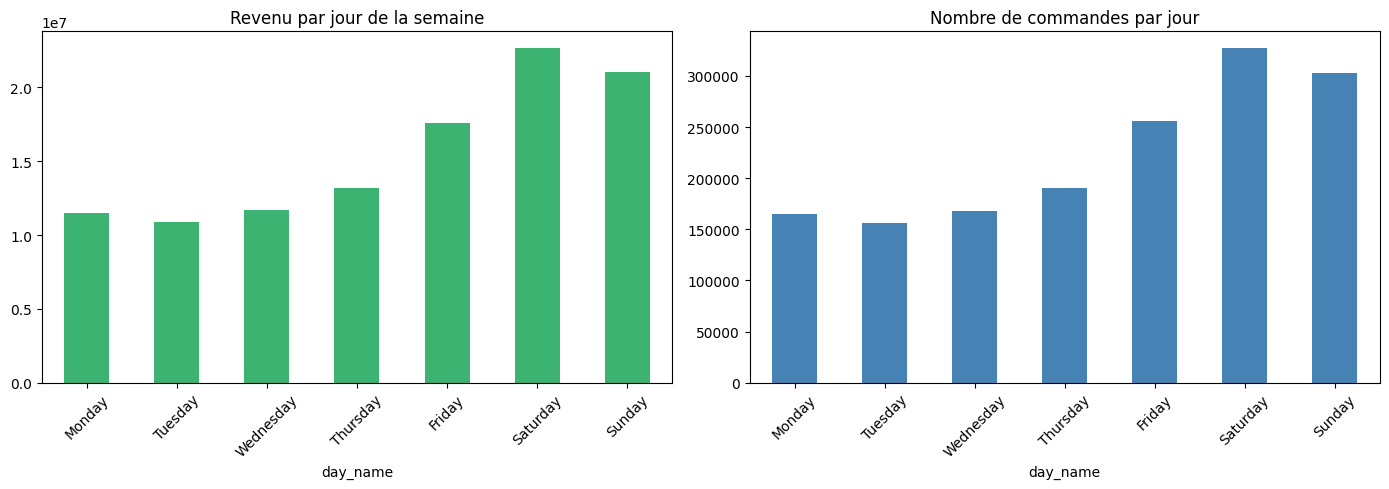

In [29]:
orders['day_of_week'] = orders['order_purchase_ts'].dt.dayofweek
orders['day_name'] = orders['order_purchase_ts'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_revenue = orders.groupby('day_name')['order_value'].sum().reindex(day_order)
dow_orders = orders.groupby('day_name')['order_id'].count().reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dow_revenue.plot(kind='bar', ax=axes[0], color='mediumseagreen')
axes[0].set_title('Revenu par jour de la semaine')
axes[0].tick_params(axis='x', rotation=45)

dow_orders.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Nombre de commandes par jour')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [30]:
Q1 = orders['order_value'].quantile(0.25)
Q3 = orders['order_value'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = orders[(orders['order_value'] < lower_bound) | (orders['order_value'] > upper_bound)]

print(f"Bornes IQR: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Outliers détectés: {len(outliers)} ({len(outliers)/len(orders)*100:.2f}%)")

orders['is_outlier'] = ((orders['order_value'] < lower_bound) | (orders['order_value'] > upper_bound)).astype(int)

Bornes IQR: [-54.13, 153.95]
Outliers détectés: 155656 (9.95%)


In [31]:
orders_clean = orders.copy()

# 1. Doublons sur order_id
n_dup = orders_clean.duplicated(subset='order_id').sum()
orders_clean = orders_clean.drop_duplicates(subset='order_id')
print(f"✅ Doublons supprimés sur order_id: {n_dup}")

# 2. Statuts invalides
valid_statuses = ['delivered', 'shipped', 'processing', 'canceled', 'unavailable', 'invoiced', 'approved']
orders_clean = orders_clean[orders_clean['order_status'].isin(valid_statuses)]
print(f"✅ Statuts valides conservés: {len(orders_clean)} commandes")

# 3. Valeurs négatives ou nulles sur order_value
n_neg = (orders_clean['order_value'] <= 0).sum()
orders_clean = orders_clean[orders_clean['order_value'] > 0]
print(f"✅ Commandes avec order_value <= 0 supprimées: {n_neg}")

# 4. Vérification des types
orders_clean['order_approved_ts'] = pd.to_datetime(orders_clean['order_approved_ts'], errors='coerce')
orders_clean['order_delivered_ts'] = pd.to_datetime(orders_clean['order_delivered_ts'], errors='coerce')
orders_clean['order_estimated_delivery'] = pd.to_datetime(orders_clean['order_estimated_delivery'], errors='coerce')

print(f"\n📊 orders_clean final: {orders_clean.shape}")
print(f"Période: {orders_clean['order_purchase_ts'].min()} → {orders_clean['order_purchase_ts'].max()}")

✅ Doublons supprimés sur order_id: 0
✅ Statuts valides conservés: 1564619 commandes
✅ Commandes avec order_value <= 0 supprimées: 0

📊 orders_clean final: (1564619, 18)
Période: 2022-01-01 00:07:46 → 2025-12-31 23:55:16


In [32]:
orders_clean['year'] = orders_clean['order_purchase_ts'].dt.year
orders_clean['month'] = orders_clean['order_purchase_ts'].dt.month
orders_clean['week'] = orders_clean['order_purchase_ts'].dt.isocalendar().week.astype(int)
orders_clean['day_of_week'] = orders_clean['order_purchase_ts'].dt.dayofweek
orders_clean['is_weekend'] = orders_clean['day_of_week'].isin([5, 6]).astype(int)
orders_clean['quarter'] = orders_clean['order_purchase_ts'].dt.quarter

orders_clean['delivery_days'] = (
    orders_clean['order_delivered_ts'] - orders_clean['order_purchase_ts']
).dt.days

orders_clean['is_late'] = (
    orders_clean['order_delivered_ts'] > orders_clean['order_estimated_delivery']
).astype(int)

print("✅ Features temporelles et livraison créées")
print(orders_clean[['year', 'month', 'week', 'day_of_week', 'delivery_days', 'is_late']].describe())

✅ Features temporelles et livraison créées
               year         month          week   day_of_week  delivery_days  \
count  1.564619e+06  1.564619e+06  1.564619e+06  1.564619e+06   1.548882e+06   
mean   2.024031e+03  7.445703e+00  3.056592e+01  3.541040e+00   4.255929e+00   
std    9.878480e-01  3.685111e+00  1.608488e+01  1.975660e+00   1.735286e+00   
min    2.022000e+03  1.000000e+00  1.000000e+00  0.000000e+00   0.000000e+00   
25%    2.023000e+03  4.000000e+00  1.600000e+01  2.000000e+00   3.000000e+00   
50%    2.024000e+03  8.000000e+00  3.400000e+01  4.000000e+00   4.000000e+00   
75%    2.025000e+03  1.100000e+01  4.600000e+01  5.000000e+00   5.000000e+00   
max    2.025000e+03  1.200000e+01  5.200000e+01  6.000000e+00   1.500000e+01   

            is_late  
count  1.564619e+06  
mean   6.901175e-01  
std    4.624451e-01  
min    0.000000e+00  
25%    0.000000e+00  
50%    1.000000e+00  
75%    1.000000e+00  
max    1.000000e+00  


In [33]:
# ⚠️ order_items contient DÉJÀ : product_id, brand_id, category, unit_price, unit_cost
# On ne ramène QUE les colonnes absentes de products : cost, retail_price, brand_tier, weight_g
items_enriched = order_items.merge(
    products[['product_id', 'cost', 'retail_price', 'brand_tier', 'weight_g']],
    on='product_id',
    how='left'
)

# Marge : utiliser unit_cost (déjà dans order_items) si dispo, sinon cost (de products)
items_enriched['margin'] = items_enriched['unit_price'] - items_enriched['unit_cost']
items_enriched['margin_pct'] = items_enriched['margin'] / items_enriched['unit_price']

print("✅ Features produit et marge créées")
print(f"items_enriched: {items_enriched.shape}")
print(f"Colonnes: {list(items_enriched.columns)}")
print(items_enriched[['unit_price', 'unit_cost', 'margin', 'margin_pct']].describe())

# Marge par catégorie (category vient de order_items)
margin_by_cat = items_enriched.groupby('category').agg({
    'margin': 'mean',
    'margin_pct': 'mean',
    'unit_price': 'mean'
}).round(2).sort_values('margin_pct', ascending=False)

print("\n📊 Marge moyenne par catégorie (top 10):")
print(margin_by_cat.head(10))

✅ Features produit et marge créées
items_enriched: (2372597, 13)
Colonnes: ['order_id', 'order_item_id', 'product_id', 'brand_id', 'category', 'unit_price', 'unit_cost', 'cost', 'retail_price', 'brand_tier', 'weight_g', 'margin', 'margin_pct']
         unit_price     unit_cost        margin    margin_pct
count  2.372597e+06  2.372597e+06  2.372597e+06  2.372597e+06
mean   4.417054e+01  2.340284e+01  2.076770e+01  4.609439e-01
std    5.620076e+01  2.947376e+01  2.745825e+01  9.118315e-02
min    9.800000e-01  6.800000e-01  0.000000e+00  0.000000e+00
25%    1.231000e+01  6.520000e+00  5.560000e+00  4.497126e-01
50%    2.533000e+01  1.275000e+01  1.115000e+01  5.000000e-01
75%    5.711000e+01  3.099000e+01  3.085000e+01  5.005549e-01
max    5.583000e+02  2.791500e+02  2.791500e+02  5.520000e-01

📊 Marge moyenne par catégorie (top 10):
                    margin  margin_pct  unit_price
category                                          
nails                 5.01        0.51        9.59
make

In [34]:
reference_date = orders_clean['order_purchase_ts'].max() + pd.Timedelta(days=1)
print(f"Date de référence RFM: {reference_date}")

rfm = orders_clean.groupby('customer_unique_id').agg({
    'order_purchase_ts': lambda x: (reference_date - x.max()).days,
    'order_id': 'count',
    'order_value': 'sum'
}).rename(columns={
    'order_purchase_ts': 'recency',
    'order_id': 'frequency',
    'order_value': 'monetary'
})

print(f"\n📊 RFM shape: {rfm.shape}")
print(rfm.describe())

Date de référence RFM: 2026-01-01 23:55:16

📊 RFM shape: (986512, 3)
             recency      frequency       monetary
count  986512.000000  986512.000000  986512.000000
mean      547.703256       1.586011     110.018421
std       409.381078       1.373181     134.387677
min         1.000000       1.000000       4.880000
25%       193.000000       1.000000      30.280000
50%       461.000000       1.000000      61.980000
75%       830.000000       2.000000     130.110000
max      1461.000000      37.000000    3037.320000


📊 Distribution des segments RFM:
segment
Need Attention     371579
Loyal Customers    195935
Lost               182104
Champions          162264
At Risk             47882
Promising           26622
New Customers         126
Name: count, dtype: int64


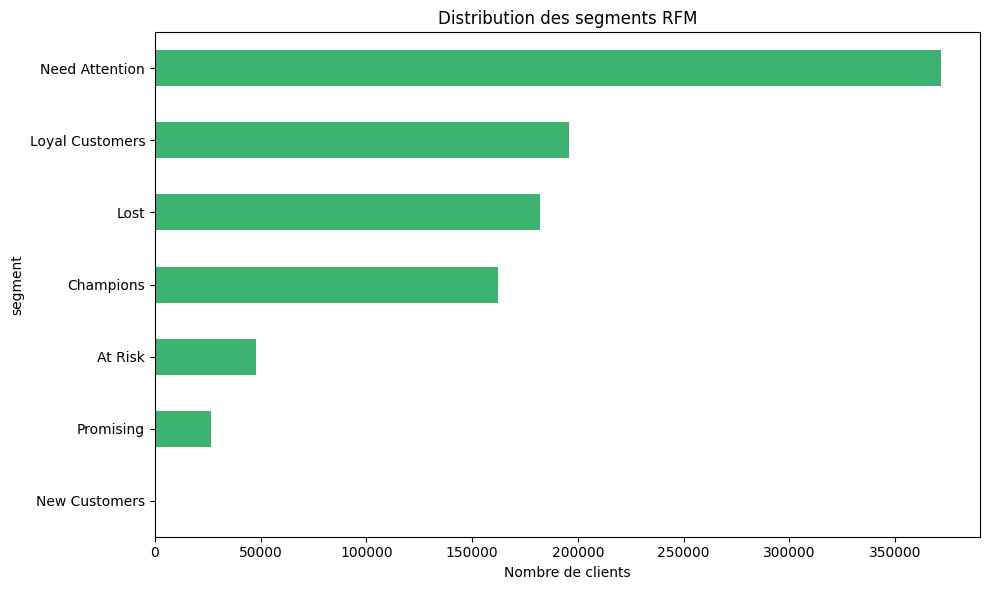

In [35]:
rfm['R_score'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

def segment_customer(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    elif r >= 3 and f <= 2 and m <= 2:
        return 'Promising'
    else:
        return 'Need Attention'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

seg_dist = rfm['segment'].value_counts()
print("📊 Distribution des segments RFM:")
print(seg_dist)

fig, ax = plt.subplots(figsize=(10, 6))
seg_dist.plot(kind='barh', ax=ax, color='mediumseagreen')
ax.set_title('Distribution des segments RFM')
ax.set_xlabel('Nombre de clients')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [36]:
segment_profile = rfm.groupby('segment').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': ['mean', 'sum', 'count']
}).round(2)

segment_profile.columns = ['recency_mean', 'frequency_mean', 'monetary_mean', 'monetary_sum', 'n_customers']
segment_profile = segment_profile.sort_values('monetary_sum', ascending=False)

print("📊 Profil des segments RFM:")
print(segment_profile)

segment_profile['revenue_share_%'] = (
    segment_profile['monetary_sum'] / segment_profile['monetary_sum'].sum() * 100
).round(2)

print("\n💰 Part du revenu par segment:")
print(segment_profile[['n_customers', 'monetary_sum', 'revenue_share_%']])

📊 Profil des segments RFM:
                 recency_mean  frequency_mean  monetary_mean  monetary_sum  \
segment                                                                      
Champions              128.56            3.28         259.74   42145755.63   
Need Attention         594.07            1.05          73.48   27302338.92   
Loyal Customers        316.81            1.64         130.48   25565726.36   
At Risk                847.96            2.32         169.06    8094847.08   
Lost                   992.79            1.00          25.93    4722469.72   
Promising              571.45            1.00          26.06     693773.39   
New Customers          254.51            1.00          76.05       9581.83   

                 n_customers  
segment                       
Champions             162264  
Need Attention        371579  
Loyal Customers       195935  
At Risk                47882  
Lost                  182104  
Promising              26622  
New Customers         

📊 Nombre de clients dans RFM : 986,512
📊 Échantillon silhouette : 10,000 points

🔄 Boucle Elbow + Silhouette en cours...
  k= 2 | inertie=     1912085 | silhouette=0.609 | 1.4s
  k= 3 | inertie=     1251174 | silhouette=0.428 | 1.3s
  k= 4 | inertie=      920350 | silhouette=0.438 | 1.2s
  k= 5 | inertie=      842613 | silhouette=0.407 | 1.2s
  k= 6 | inertie=      698907 | silhouette=0.372 | 1.3s
  k= 7 | inertie=      643063 | silhouette=0.367 | 1.2s
  k= 8 | inertie=      548619 | silhouette=0.347 | 1.2s
  k= 9 | inertie=      515032 | silhouette=0.395 | 1.2s
  k=10 | inertie=      465999 | silhouette=0.401 | 1.2s


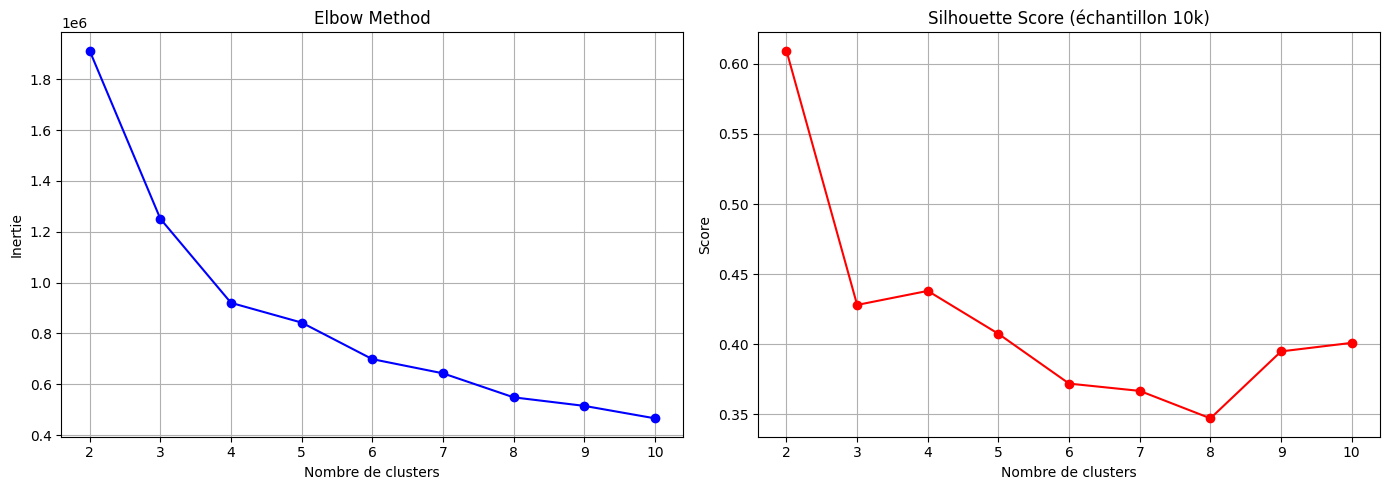


✅ Meilleur k selon Silhouette: 2
Silhouette scores: {2: np.float64(0.609), 3: np.float64(0.428), 4: np.float64(0.438), 5: np.float64(0.407), 6: np.float64(0.372), 7: np.float64(0.367), 8: np.float64(0.347), 9: np.float64(0.395), 10: np.float64(0.401)}


In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.impute import SimpleImputer
import time

# ============================================
# DIAGNOSTIC DE TAILLE
# ============================================
print(f"📊 Nombre de clients dans RFM : {len(rfm):,}")

# ============================================
# PRÉPARATION DES FEATURES
# ============================================
rfm_features = rfm[['recency', 'frequency', 'monetary']].copy()

imputer = SimpleImputer(strategy='median')
rfm_imputed = imputer.fit_transform(rfm_features)

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_imputed)

n_samples = rfm_scaled.shape[0]

# ============================================
# ÉCHANTILLONNAGE POUR SILHOUETTE (crucial !)
# silhouette_score est O(n²) → on échantillonne si n > 10 000
# ============================================
SILHOUETTE_SAMPLE = min(10_000, n_samples)
rng = np.random.RandomState(42)
sil_sample_idx = rng.choice(n_samples, size=SILHOUETTE_SAMPLE, replace=False)
rfm_sample = rfm_scaled[sil_sample_idx]
print(f"📊 Échantillon silhouette : {SILHOUETTE_SAMPLE:,} points")

# ============================================
# ELBOW + SILHOUETTE AVEC MINIBATCHKMEANS
# ============================================
inertias = []
silhouettes = []
K_range = list(range(2, 11))

print("\n🔄 Boucle Elbow + Silhouette en cours...")
for k in K_range:
    t0 = time.time()

    km = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        n_init=3,
        batch_size=1024,
        max_iter=100
    )
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)

    # Silhouette sur échantillon uniquement
    sil = silhouette_score(rfm_sample, labels[sil_sample_idx])
    silhouettes.append(sil)

    elapsed = time.time() - t0
    print(f"  k={k:2d} | inertie={km.inertia_:12.0f} | silhouette={sil:.3f} | {elapsed:.1f}s")

# ============================================
# VISUALISATION
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Nombre de clusters')
axes[0].set_ylabel('Inertie')
axes[0].grid(True)

axes[1].plot(K_range, silhouettes, 'ro-')
axes[1].set_title('Silhouette Score (échantillon 10k)')
axes[1].set_xlabel('Nombre de clusters')
axes[1].set_ylabel('Score')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# ============================================
# MEILLEUR K
# ============================================
best_k = K_range[int(np.argmax(silhouettes))]
print(f"\n✅ Meilleur k selon Silhouette: {best_k}")
print(f"Silhouette scores: {dict(zip(K_range, [round(s, 3) for s in silhouettes]))}")

In [38]:
import time

# ============================================
# ENTRAÎNEMENT FINAL AVEC KMEANS CLASSIQUE
# ============================================
t0 = time.time()
kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=5,
    max_iter=300
)
rfm['cluster'] = kmeans_final.fit_predict(rfm_scaled)
print(f"⏱️ Entraînement final : {time.time() - t0:.1f}s")

# ============================================
# MÉTRIQUES FINALES
# ============================================
sil_final = silhouette_score(rfm_sample, rfm['cluster'].values[sil_sample_idx])
db_final = davies_bouldin_score(rfm_scaled, rfm['cluster'])

print(f"✅ Silhouette Score final: {sil_final:.3f}")
print(f"✅ Davies-Bouldin Index: {db_final:.3f}")

# ============================================
# PROFILING DES CLUSTERS
# ============================================
cluster_profile = rfm.groupby('cluster').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': ['mean', 'sum', 'count']
}).round(2)

cluster_profile.columns = ['recency', 'frequency', 'monetary_mean', 'monetary_sum', 'n_customers']
cluster_profile['revenue_share_%'] = (
    cluster_profile['monetary_sum'] / cluster_profile['monetary_sum'].sum() * 100
).round(2)

print("\n📊 Profil des clusters K-Means:")
print(cluster_profile.sort_values('monetary_sum', ascending=False))

⏱️ Entraînement final : 1.4s
✅ Silhouette Score final: 0.566
✅ Davies-Bouldin Index: 0.878

📊 Profil des clusters K-Means:
         recency  frequency  monetary_mean  monetary_sum  n_customers  \
cluster                                                                 
1         582.12       1.26          79.21   70520874.67       890322   
0         229.14       4.62         395.19   38013618.26        96190   

         revenue_share_%  
cluster                   
1                  64.98  
0                  35.02  


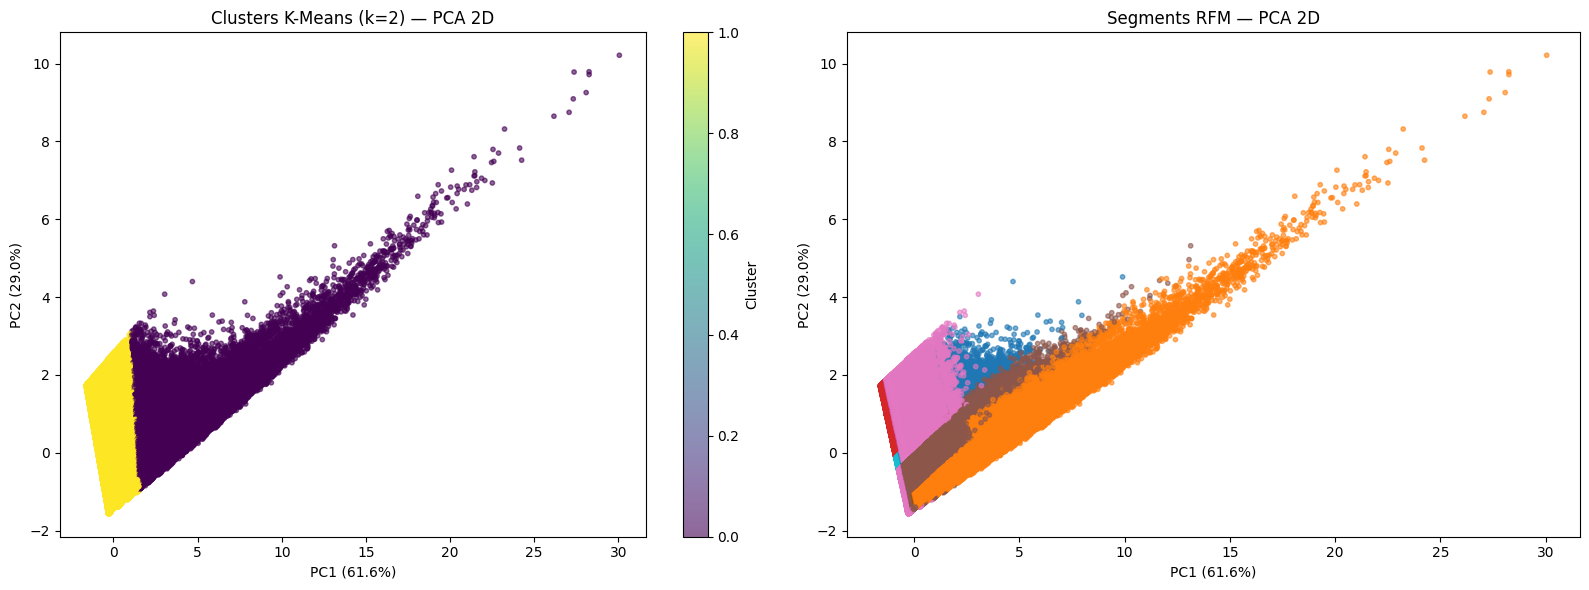

Variance expliquée par les 2 premières composantes: 90.6%


In [39]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter = axes[0].scatter(
    rfm_pca[:, 0], rfm_pca[:, 1],
    c=rfm['cluster'], cmap='viridis', alpha=0.6, s=10
)
axes[0].set_title(f'Clusters K-Means (k={best_k}) — PCA 2D')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(scatter, ax=axes[0], label='Cluster')

segment_codes = pd.Categorical(rfm['segment']).codes
scatter2 = axes[1].scatter(
    rfm_pca[:, 0], rfm_pca[:, 1],
    c=segment_codes, cmap='tab10', alpha=0.6, s=10
)
axes[1].set_title('Segments RFM — PCA 2D')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

plt.tight_layout()
plt.show()

print(f"Variance expliquée par les 2 premières composantes: {pca.explained_variance_ratio_[:2].sum()*100:.1f}%")

Série hebdomadaire: 210 semaines
Période: 2022-01-02 00:00:00 → 2026-01-04 00:00:00


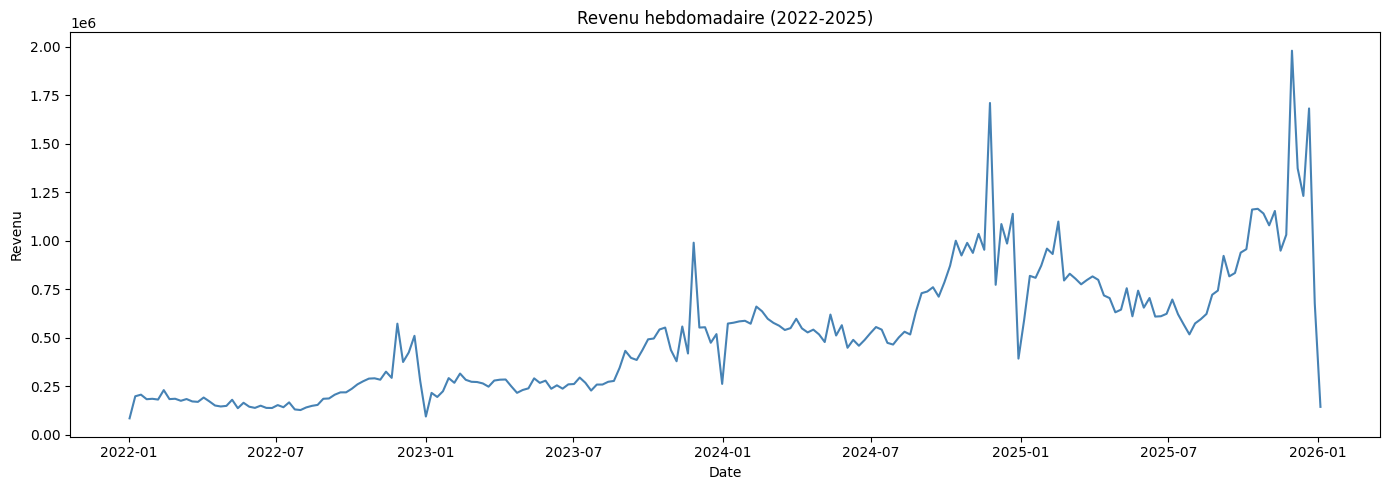

In [40]:
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

weekly_revenue = (
    orders_clean
    .set_index('order_purchase_ts')['order_value']
    .resample('W')
    .sum()
)

print(f"Série hebdomadaire: {len(weekly_revenue)} semaines")
print(f"Période: {weekly_revenue.index.min()} → {weekly_revenue.index.max()}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(weekly_revenue.index, weekly_revenue.values, color='steelblue')
ax.set_title('Revenu hebdomadaire (2022-2025)')
ax.set_xlabel('Date')
ax.set_ylabel('Revenu')
plt.tight_layout()
plt.show()

In [41]:
train_size = int(len(weekly_revenue) * 0.8)
train_ts = weekly_revenue[:train_size]
test_ts = weekly_revenue[train_size:]

print(f"Train: {train_ts.index.min()} → {train_ts.index.max()} ({len(train_ts)} semaines)")
print(f"Test:  {test_ts.index.min()} → {test_ts.index.max()} ({len(test_ts)} semaines)")

def evaluate_forecast(actual, predicted, model_name):
    actual = np.array(actual)
    predicted = np.array(predicted)
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mask = actual != 0
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100
    print(f"{model_name:20s} | MAE: {mae:10.2f} | RMSE: {rmse:10.2f} | MAPE: {mape:6.2f}%")
    return {'model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

results = []

# Baseline 1 : Naive
naive_pred = pd.Series([train_ts.iloc[-1]] * len(test_ts), index=test_ts.index)
results.append(evaluate_forecast(test_ts, naive_pred, 'Naive'))

# Baseline 2 : Moving Average (4 semaines)
ma_pred = pd.Series([train_ts.tail(4).mean()] * len(test_ts), index=test_ts.index)
results.append(evaluate_forecast(test_ts, ma_pred, 'Moving Avg (4w)'))

# Baseline 3 : Seasonal Naive (décalage 52 semaines)
if len(train_ts) >= 52:
    seasonal_naive = train_ts.shift(52).iloc[-len(test_ts):].values
    seasonal_naive = pd.Series(seasonal_naive, index=test_ts.index)
    results.append(evaluate_forecast(test_ts, seasonal_naive, 'Seasonal Naive'))

Train: 2022-01-02 00:00:00 → 2025-03-16 00:00:00 (168 semaines)
Test:  2025-03-23 00:00:00 → 2026-01-04 00:00:00 (42 semaines)
Naive                | MAE:  224406.93 | RMSE:  327378.22 | MAPE:  32.16%
Moving Avg (4w)      | MAE:  227181.80 | RMSE:  323228.69 | MAPE:  33.58%
Seasonal Naive       | MAE:  420038.07 | RMSE:  495613.24 | MAPE:  51.55%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


SARIMA               | MAE:  217143.05 | RMSE:  354023.79 | MAPE:  46.48%


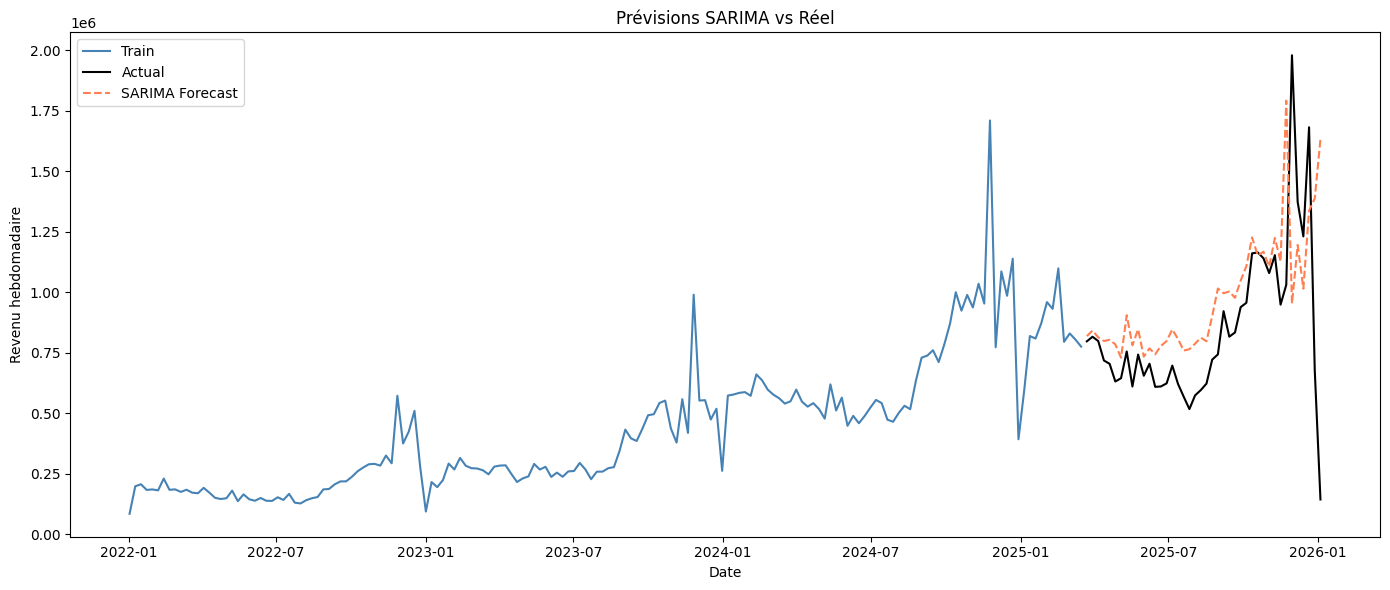

                                     SARIMAX Results                                      
Dep. Variable:                        order_value   No. Observations:                  168
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 52)   Log Likelihood                -779.270
Date:                            Thu, 17 Sep 2026   AIC                           1568.540
Time:                                    10:56:39   BIC                           1579.095
Sample:                                01-02-2022   HQIC                          1572.677
                                     - 03-16-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2185      0.284     -0.771      0.441      -0.774       0.337
ma.L1         -0.5466      0.229   

In [42]:
sarima_model = SARIMAX(
    train_ts,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_results = sarima_model.fit(disp=False)

sarima_forecast = sarima_results.forecast(steps=len(test_ts))
sarima_forecast.index = test_ts.index

results.append(evaluate_forecast(test_ts, sarima_forecast, 'SARIMA'))

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train_ts.index, train_ts.values, label='Train', color='steelblue')
ax.plot(test_ts.index, test_ts.values, label='Actual', color='black')
ax.plot(test_ts.index, sarima_forecast.values, label='SARIMA Forecast', color='coral', linestyle='--')
ax.set_title('Prévisions SARIMA vs Réel')
ax.set_xlabel('Date')
ax.set_ylabel('Revenu hebdomadaire')
ax.legend()
plt.tight_layout()
plt.show()

print(sarima_results.summary())

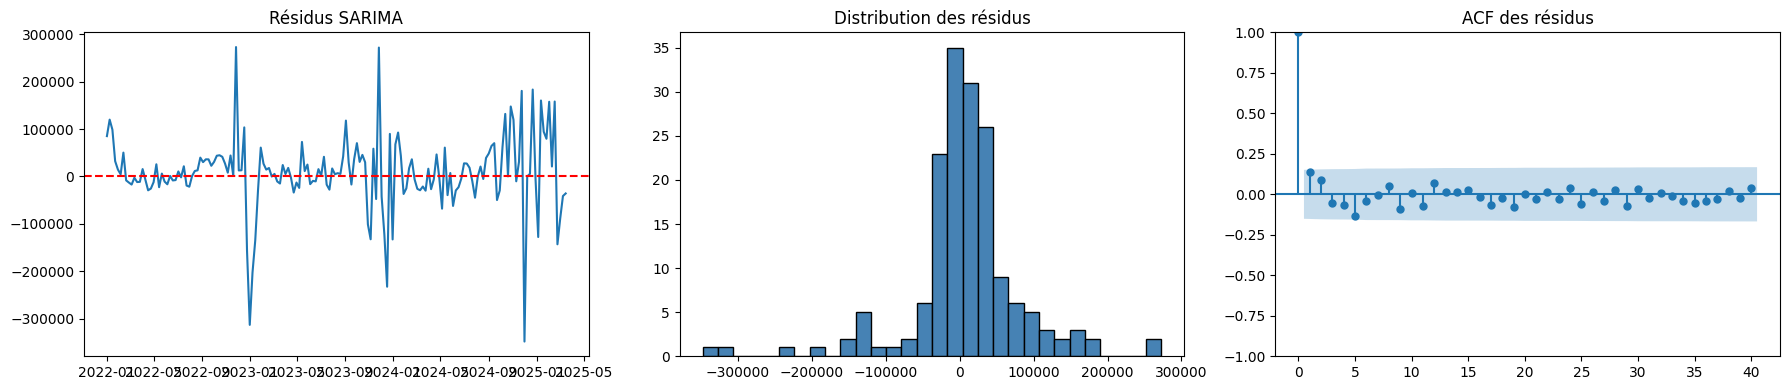

Shapiro-Wilk test: stat=0.8747, p-value=0.0000
⚠️ Résidus non normaux — modèle à améliorer


In [43]:
residuals = sarima_results.resid

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(residuals)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_title('Résidus SARIMA')

axes[1].hist(residuals, bins=30, edgecolor='black', color='steelblue')
axes[1].set_title('Distribution des résidus')

sm.graphics.tsa.plot_acf(residuals.dropna(), lags=40, ax=axes[2])
axes[2].set_title('ACF des résidus')

plt.tight_layout()
plt.show()

from scipy import stats
stat, p_value = stats.shapiro(residuals.dropna())
print(f"Shapiro-Wilk test: stat={stat:.4f}, p-value={p_value:.4f}")
if p_value > 0.05:
    print("✅ Résidus compatibles avec une distribution normale")
else:
    print("⚠️ Résidus non normaux — modèle à améliorer")

In [44]:
output_path = '/kaggle/working/'

# 1. RFM + clusters
rfm.reset_index().to_csv(os.path.join(output_path, 'rfm_segments.csv'), index=False)
print(f"✅ rfm_segments.csv exporté ({rfm.shape})")

# 2. Prévisions hebdomadaires
forecast_df = pd.DataFrame({
    'date': test_ts.index,
    'actual': test_ts.values,
    'sarima_forecast': sarima_forecast.values
})
forecast_df.to_csv(os.path.join(output_path, 'weekly_forecast.csv'), index=False)
print(f"✅ weekly_forecast.csv exporté ({forecast_df.shape})")

# 3. KPIs globaux
kpi_df = pd.DataFrame({
    'metric': ['total_revenue', 'total_orders', 'total_customers', 'aov', 'avg_frequency'],
    'value': [
        orders_clean['order_value'].sum(),
        len(orders_clean),
        orders_clean['customer_unique_id'].nunique(),
        orders_clean['order_value'].mean(),
        orders_clean.groupby('customer_unique_id')['order_id'].count().mean()
    ]
})
kpi_df.to_csv(os.path.join(output_path, 'global_kpis.csv'), index=False)
print(f"✅ global_kpis.csv exporté")
print(kpi_df)

# 4. Ventes par catégorie
category_sales = (
    items_enriched
    .groupby('category')
    .agg({'unit_price': 'sum', 'margin': 'sum'})
    .reset_index()
)
category_sales.to_csv(os.path.join(output_path, 'category_sales.csv'), index=False)
print(f"✅ category_sales.csv exporté ({category_sales.shape})")

# 5. Segments RFM (agrégat)
segment_summary = rfm.groupby('segment').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': ['mean', 'sum', 'count']
}).round(2).reset_index()
segment_summary.columns = ['segment', 'recency', 'frequency', 'monetary_mean', 'monetary_sum', 'n_customers']
segment_summary.to_csv(os.path.join(output_path, 'segment_summary.csv'), index=False)
print(f"✅ segment_summary.csv exporté ({segment_summary.shape})")

print(f"\n📁 Fichiers exportés dans {output_path}:")
for f in os.listdir(output_path):
    if f.endswith('.csv'):
        print(f"  - {f}")

✅ rfm_segments.csv exporté ((986512, 9))
✅ weekly_forecast.csv exporté ((42, 3))
✅ global_kpis.csv exporté
            metric         value
0    total_revenue  1.085345e+08
1     total_orders  1.564619e+06
2  total_customers  9.865120e+05
3              aov  6.936800e+01
4    avg_frequency  1.586011e+00
✅ category_sales.csv exporté ((17, 3))
✅ segment_summary.csv exporté ((7, 6))

📁 Fichiers exportés dans /kaggle/working/:
  - weekly_forecast.csv
  - segment_summary.csv
  - global_kpis.csv
  - rfm_segments.csv
  - category_sales.csv


In [45]:
print("="*70)
print("📊 RÉSUMÉ EXÉCUTIF — Beauty E-Commerce Analytics")
print("="*70)

total_rev = orders_clean['order_value'].sum()
total_orders = len(orders_clean)
total_customers = orders_clean['customer_unique_id'].nunique()
aov = orders_clean['order_value'].mean()

print(f"\n💰 REVENUE")
print(f"  - Revenu total: {total_rev:,.2f}")
print(f"  - Commandes: {total_orders:,}")
print(f"  - Clients uniques: {total_customers:,}")
print(f"  - AOV: {aov:.2f}")

print(f"\n👥 SEGMENTATION CLIENT")
print(f"  - Segments RFM identifiés: {rfm['segment'].nunique()}")
print(f"  - Clusters K-Means: {best_k}")
print(f"  - Silhouette Score: {sil_final:.3f}")

print(f"\n📈 FORECASTING")
print(f"  - Meilleur modèle: {best_model}")
best_row = results_df.iloc[0]
print(f"  - MAE: {best_row['MAE']:.2f}")
print(f"  - RMSE: {best_row['RMSE']:.2f}")
print(f"  - MAPE: {best_row['MAPE']:.2f}%")

print(f"\n🎯 TOP SEGMENTS PAR REVENU:")
top_seg = segment_profile.sort_values('monetary_sum', ascending=False).head(3)
print(top_seg[['n_customers', 'monetary_sum', 'revenue_share_%']])

print("\n" + "="*70)

📊 RÉSUMÉ EXÉCUTIF — Beauty E-Commerce Analytics

💰 REVENUE
  - Revenu total: 108,534,492.93
  - Commandes: 1,564,619
  - Clients uniques: 986,512
  - AOV: 69.37

👥 SEGMENTATION CLIENT
  - Segments RFM identifiés: 7
  - Clusters K-Means: 2
  - Silhouette Score: 0.566

📈 FORECASTING


NameError: name 'best_model' is not defined